# Prompt Generation

In [1]:
answ_eval_ROLE = """
You are a helpful assistant responsible for grading two answers to a question that are provided by two different people.
"""

answ_eval_ASSESSMENT = """
Your assessment should include two parts:
- Winner: either 1 (if Answer 1 is better) and 2 (if Answer 2 is better) or 0 if they are fundamentally similar \
  and the differences are immaterial.
- Reasoning: a short explanation of why you chose the winner with respect to the measure described above.
"""

answ_eval_FORMAT = """
Format your response as a JSON object with the following structure:
{{
 "winner": <1, 2, or 0>,
 "reasoning": "Answer 1 is better because <your reasoning>."
}}
"""

In [10]:
CRITERIA = {'comprehensiveness': 'To what extent does the answer fully and accurately address all relevant aspects of the question?     A comprehensive answer should be complete, well-organized, and free from redundancy or irrelevant details. For instance,     if asked about the pros and cons of nuclear energy, a good answer should include both advantages (e.g., efficiency, low     emissions) and disadvantages (e.g., waste, safety risks).',
 'diversity': 'How well does the answer present a range of perspectives, insights, or sources on the topic? A diverse answer     should explore multiple dimensions of the question and avoid being one-sided or relying on a single source. For example, a     question about climate change should include various causes, effects, and viewpoints (e.g., scientific, social, economic).',
 'directness': "How clearly and specifically does the answer respond to the question? A direct answer should be concise and     to the point, avoiding irrelevant information or vague language. For example, the question 'What is the capital of France?'     should be answered simply as 'Paris' without unnecessary elaboration.",
 'empowerment': 'Does the answer help the reader understand the topic and make informed decisions? An empowering answer should     explain its reasoning clearly, avoid misleading claims, and provide support or evidence where appropriate, helping the reader     build accurate knowledge.'}

## Load Questions

In [4]:
import pandas as pd

question_df = pd.read_pickle('questions_cache_gemma2_all-mpnet-base-v2.pkl')
question_df

,User,Task,Questions
0,User1,Investigating the impact of genetic variants o...,"[Q1. How do specific genetic variants, such as..."
1,User1,Exploring the relationship between genetic var...,[Q1. What is the relationship between genetic ...
2,User1,Analyzing the impact of nutrigenetic insights ...,[Q1. How can genetic information be used to ta...
3,User1,Investigating the role of epigenetics in nutri...,[Q1. What is the role of epigenetic modificati...
4,User1,Examining the intersection of nutrigenetics an...,"[Q1. How do environmental factors, like air po..."
5,User2,Integrating nutrigenetic insights into clinica...,[Q1. How can healthcare professionals use gene...
6,User2,Applying nutrigenetic insights to disease prev...,[Q1. How can nutrigenetic insights inform the ...
7,User2,Exploring the role of nutrigenetics in persona...,[Q1. How can nutrigenetic insights be used to ...
8,User2,Investigating the intersection of nutrigenetic...,[Q1. What are the implications of nutrigenetic...
9,User2,Examining the role of nutrigenetics in health ...,[Q1. How do genetic variants contribute to hea...


# Load Answers

In [ ]:
import pandas as pd

answer_df = pd.read_csv("answers_cache_gemma2_all-mpnet-base-v2.csv")
answer_df

,Unnamed: 0,User,Task,Question,GraphRAG-Answer,Naive-RAG-Answer,No-RAG-Answer
0,0,User1,Investigating the impact of genetic variants o...,"Q1. How do specific genetic variants, such as ...",**Introduction to Genetic Variants and Metabol...,"Specific genetic variants, such as TCF7L2 and ...",## Step 1: Understanding the Genetic Variants\...
1,1,User1,Investigating the impact of genetic variants o...,Q2. What is the role of molecular interactions...,## Introduction\nThe molecular interactions be...,## Step 1: Understanding the Role of Molecular...,## Step 1: Understanding the Role of Molecular...
2,2,User1,Investigating the impact of genetic variants o...,"Q3. How do dietary patterns, such as fiber int...",**Interactions Between Dietary Patterns and Ge...,## Interactions between Dietary Patterns and G...,## Step 1: Understanding the Basics\nTo approa...
3,3,User1,Investigating the impact of genetic variants o...,Q4. Can genetic variants in the OPRM1 gene inf...,## Introduction\nThe relationship between gene...,"Yes, genetic variants in the OPRM1 gene can in...",## Step 1: Understanding the OPRM1 Gene\nThe O...
4,4,User1,Investigating the impact of genetic variants o...,"Q5. How do environmental factors, like smoking...",**Environmental Factors and Gene-Nutrient Inte...,"## Interactions Between Genes, Nutrients, and ...",## Step 1: Understanding the Interplay Between...
5,5,User1,Exploring the relationship between genetic var...,Q1. What is the relationship between genetic v...,The Relationship Between Genetic Variants and ...,"The relationship between genetic variants, suc...","The relationship between genetic variants, suc..."
6,6,User1,Exploring the relationship between genetic var...,"Q2. How do genetic predispositions, such as SN...",**Genetic Predispositions and Lifestyle Factor...,## Interactions Between Genetic Predisposition...,The fascinating interplay between genetic pred...
7,7,User1,Exploring the relationship between genetic var...,Q3. Can genetic variants in the WFS1 gene infl...,## Introduction\nThe relationship between gene...,## Genetic Variants in WFS1 Gene and Type 2 Di...,"The WFS1 gene, also known as the Wolfram syndr..."
8,8,User1,Exploring the relationship between genetic var...,Q4. What is the impact of genetic variants on ...,The Impact of Genetic Variants on the Gut Micr...,The impact of genetic variants on the gut micr...,"The relationship between genetic variants, the..."
9,9,User1,Exploring the relationship between genetic var...,Q5. How do molecular interactions between gene...,Molecular Interactions Between Genetic Variant...,## Molecular Interactions between Genetic Vari...,## Step 1: Understanding the Basics of Molecul...


# Answer Evaluation: LLM-as-a-judge

In [5]:
# !pip install groq

In [ ]:
import os
from groq import Groq

MODEL = "openai/gpt-oss-20b"
MODEL = "meta-llama/llama-4-scout-17b-16e-instruct"

with open("groq_api.txt", "r") as f:
  GROQ_API_KEY = f.read()

# GROQ_API_KEY = "***"

client = Groq(
    api_key=GROQ_API_KEY,
)

In [ ]:
eval_test = []

for _, row in answer_df.iterrows():
  q = row['Question']
  answer1 = row['Naive-RAG-Answer']
  answer2 = row['GraphRAG-Answer']
  for criteria in CRITERIA.keys():
    answer_evaluation_prompt = f"""
      ---Role--
      {answ_eval_ROLE}

      ---Goal--
      Given a question and two answers (Answer 1 and Answer 2), assess which answer is better according to the following measure:
      {criteria}

      {answ_eval_ASSESSMENT}

      {answ_eval_FORMAT}

      ---Question--
      {q}

      ---Answer 1--
      {answer1}
      ---Answer 2--
      {answer2}

      Assess which answer is better according to the following measure:
      {criteria}

      Output:
    """
    chat_completion = client.chat.completions.create(
          messages=[
              {
                  "role": "user",
                  "content": answer_evaluation_prompt
              }
          ],
          model=MODEL,
      )

    evaluation = chat_completion.choices[0].message.content
    eval_test.append(evaluation)
    print(evaluation)

{
  "winner": 1,
  "reasoning": "Answer 1 is better because it provides a more detailed and multi‑layered explanation of how the variants influence metabolic pathways, covering specific mechanisms (gene expression, insulin signaling, glucose‑stimulated secretion), downstream effects (insulin sensitivity, secretion, glucose uptake), and concrete examples of diet interactions, thereby offering a more comprehensive overview than Answer 2."
}
{  
  "winner": 1,  
  "reasoning": "Answer 1 is better because it covers a broader range of mechanisms (gene expression regulation, insulin signaling, glucose‑stimulated insulin release), multiple downstream effects, and specific interactions with different dietary factors, providing a more diverse and detailed exploration of how TCF7L2 and CDKAL1 variants influence metabolic pathways and glucose metabolism."}
{"winner": 2, "reasoning": "Answer 2 is more direct because it focuses on the key points—how the variants influence metabolic pathways and the

In [32]:
len(eval_test)

48

In [40]:
criteria = {}  # Dictionary to hold the values

for q in range(1, 13):  # q from 1 to 12
    for c in range(1, 5):  # criteria from 1 to 4
        index = (q - 1) * 4 + (c - 1)
        criteria[f'criteria{c}_q{q}'] = eval_test[index]

In [75]:
import json
from collections import defaultdict


def extract_json_block(text):
    try:
        match = re.search(r'{[\s\S]*?}', text)
        if match:
            return json.loads(match.group(0))
    except json.JSONDecodeError:
        pass
    return None  # Return None if it can't parse

winners = defaultdict(dict)
reasonings = defaultdict(dict)


for key, value in criteria.items():
    if key.startswith("criteria2"):
        continue  # Skip criteria2

    parsed = extract_json_block(value)
    if parsed:
        crit_part, q_part = key.split('_q')
        crit = crit_part
        q = f'q{q_part}'

        winners[q][crit] = parsed.get('winner')
        reasonings[q][crit] = parsed.get('reasoning')
    else:
        print(f"Skipping {key}: No valid JSON found.")

In [76]:
winners

defaultdict(dict,
            {'q1': {'criteria1': 1, 'criteria3': 1, 'criteria4': 1},
             'q2': {'criteria1': 2, 'criteria3': 2, 'criteria4': 2},
             'q3': {'criteria1': 2, 'criteria3': 2, 'criteria4': 2},
             'q4': {'criteria1': 2, 'criteria3': 2, 'criteria4': 2},
             'q5': {'criteria1': 1, 'criteria3': 0, 'criteria4': 1},
             'q6': {'criteria1': 2, 'criteria3': 2, 'criteria4': 2},
             'q7': {'criteria1': 1, 'criteria3': 2, 'criteria4': 2},
             'q8': {'criteria1': 2, 'criteria3': 2, 'criteria4': 2},
             'q9': {'criteria1': 1, 'criteria3': 2, 'criteria4': 1},
             'q10': {'criteria1': 1, 'criteria3': 1, 'criteria4': 1},
             'q11': {'criteria1': 2, 'criteria3': 2, 'criteria4': 2},
             'q12': {'criteria1': 1, 'criteria3': 1, 'criteria4': 1}})

In [20]:
list(CRITERIA.keys())[0]

'comprehensiveness'

In [58]:
[winners[list(winners.keys())[x]]['criteria1'] for x in range(12)]

[1, 2, 2, 2, 1, 2, 1, 2, 1, 1, 2, 1]

In [77]:
answer_df[list(CRITERIA.keys())[0]] = [winners[list(winners.keys())[x]]['criteria1'] for x in range(12)]
answer_df[list(CRITERIA.keys())[2]] = [winners[list(winners.keys())[x]]['criteria3'] for x in range(12)]
answer_df[list(CRITERIA.keys())[3]] = [winners[list(winners.keys())[x]]['criteria4'] for x in range(12)]

answer_df

,Unnamed: 0,User,Task,Question,GraphRAG-Answer,Naive-RAG-Answer,No-RAG-Answer,comprehensiveness,directness,empowerment
0,0,User1,Investigating the impact of genetic variants o...,"Q1. How do specific genetic variants, such as ...",**Introduction to Genetic Variants and Metabol...,"Specific genetic variants, such as TCF7L2 and ...",## Step 1: Understanding the Genetic Variants\...,1,1,1
1,1,User1,Investigating the impact of genetic variants o...,Q2. What is the role of molecular interactions...,## Introduction\nThe molecular interactions be...,## Step 1: Understanding the Role of Molecular...,## Step 1: Understanding the Role of Molecular...,2,2,2
2,2,User1,Investigating the impact of genetic variants o...,"Q3. How do dietary patterns, such as fiber int...",**Interactions Between Dietary Patterns and Ge...,## Interactions between Dietary Patterns and G...,## Step 1: Understanding the Basics\nTo approa...,2,2,2
3,3,User1,Investigating the impact of genetic variants o...,Q4. Can genetic variants in the OPRM1 gene inf...,## Introduction\nThe relationship between gene...,"Yes, genetic variants in the OPRM1 gene can in...",## Step 1: Understanding the OPRM1 Gene\nThe O...,2,2,2
4,4,User1,Investigating the impact of genetic variants o...,"Q5. How do environmental factors, like smoking...",**Environmental Factors and Gene-Nutrient Inte...,"## Interactions Between Genes, Nutrients, and ...",## Step 1: Understanding the Interplay Between...,1,0,1
5,5,User1,Exploring the relationship between genetic var...,Q1. What is the relationship between genetic v...,The Relationship Between Genetic Variants and ...,"The relationship between genetic variants, suc...","The relationship between genetic variants, suc...",2,2,2
6,6,User1,Exploring the relationship between genetic var...,"Q2. How do genetic predispositions, such as SN...",**Genetic Predispositions and Lifestyle Factor...,## Interactions Between Genetic Predisposition...,The fascinating interplay between genetic pred...,1,2,2
7,7,User1,Exploring the relationship between genetic var...,Q3. Can genetic variants in the WFS1 gene infl...,## Introduction\nThe relationship between gene...,## Genetic Variants in WFS1 Gene and Type 2 Di...,"The WFS1 gene, also known as the Wolfram syndr...",2,2,2
8,8,User1,Exploring the relationship between genetic var...,Q4. What is the impact of genetic variants on ...,The Impact of Genetic Variants on the Gut Micr...,The impact of genetic variants on the gut micr...,"The relationship between genetic variants, the...",1,2,1
9,9,User1,Exploring the relationship between genetic var...,Q5. How do molecular interactions between gene...,Molecular Interactions Between Genetic Variant...,## Molecular Interactions between Genetic Vari...,## Step 1: Understanding the Basics of Molecul...,1,1,1


from matplotlib import pyplot as plt
answer_df['Unnamed: 0'].plot(kind='hist', bins=20, title='Unnamed: 0')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
answer_df['comprehensiveness'].plot(kind='hist', bins=20, title='comprehensiveness')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
answer_df['directness'].plot(kind='hist', bins=20, title='directness')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
answer_df['empowerment'].plot(kind='hist', bins=20, title='empowerment')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(answer_df['Task'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(answer_df, x='comprehensiveness', y='Task', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(answer_df['Task'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(answer_df, x='directness', y='Task', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(answer_df['Task'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(answer_df, x='empowerment', y='Task', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

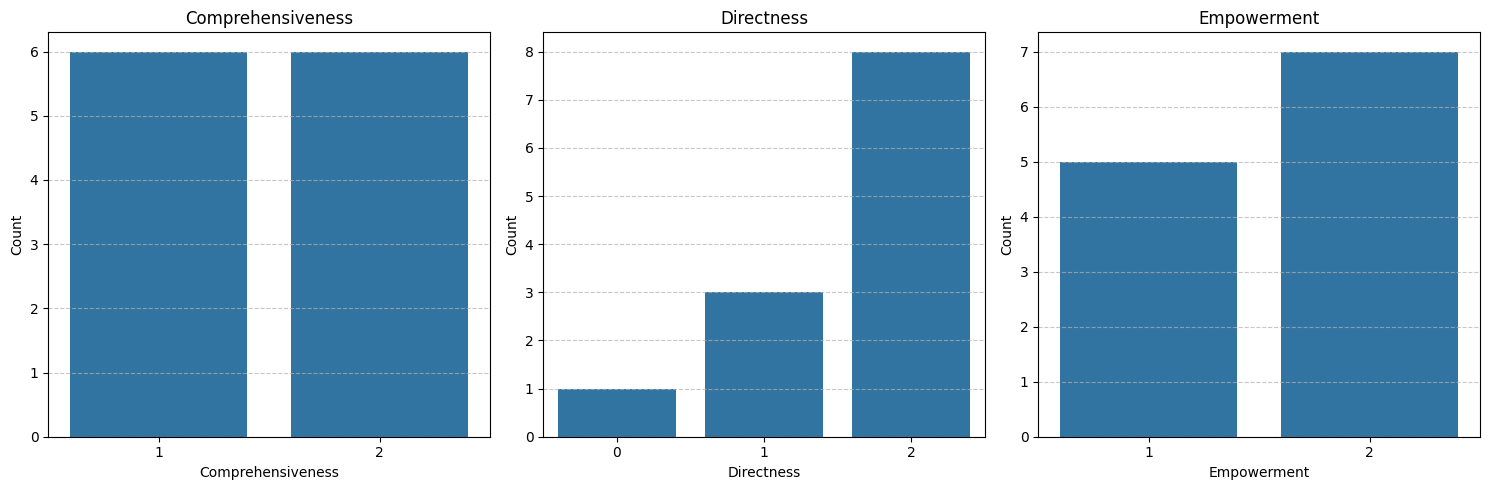

In [80]:
# prompt: plot the distribution of the comprehensiveness	directness	empowerment metrics in answer_df

import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['comprehensiveness', 'directness', 'empowerment']

plt.figure(figsize=(15, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=answer_df[metric])
    plt.title(f'{metric.capitalize()}')
    plt.xlabel(metric.capitalize())
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
answer_df

In [81]:
answer_df.to_pickle('/content/drive/MyDrive/workshop-ECAI/answer_evaluation/answer_evaluation_prova.pkl')